<a href="https://colab.research.google.com/github/Abhi0129n/Machine-learning-/blob/main/iris%20naive%20bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Load dataset

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(iris.target)


print("Dataset Shape:")
print(X.shape)

X.head()

Dataset Shape:
(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
print("Classes:")
print(iris.target_names)

print("\nClass Distribution:")
print(y.value_counts())

Classes:
['setosa' 'versicolor' 'virginica']

Class Distribution:
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


In [ ]:
# Create Gaussian Naive Bayes model

model = GaussianNB()


# Train model

model.fit(X_train, y_train)


print("Training Completed")

Training Completed


In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)


print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



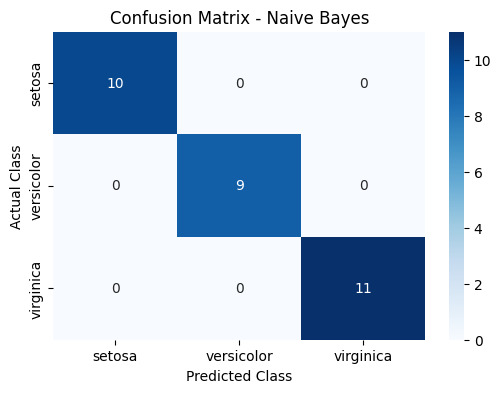

In [ ]:
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)


plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title("Confusion Matrix - Naive Bayes")

plt.show()

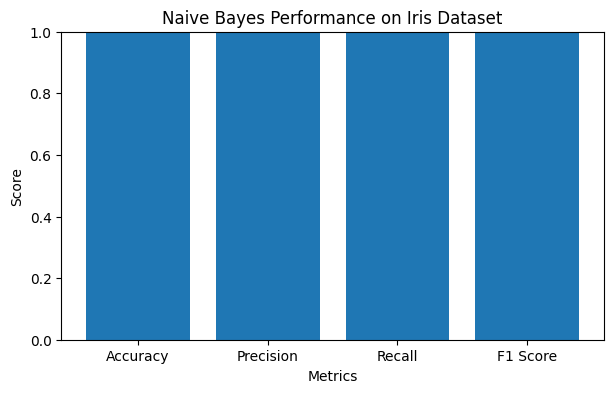

In [ ]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}


plt.figure(figsize=(7,4))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0,1)

plt.xlabel("Metrics")
plt.ylabel("Score")

plt.title("Naive Bayes Performance on Iris Dataset")

plt.show()